iris clustering - no labels used
-----------------------------------
adjusted rand score: 0.62
(1.0 = perfect, 0 = random)
-----------------------------------
cluster 0 -> points: 53
cluster 1 -> points: 50
cluster 2 -> points: 47


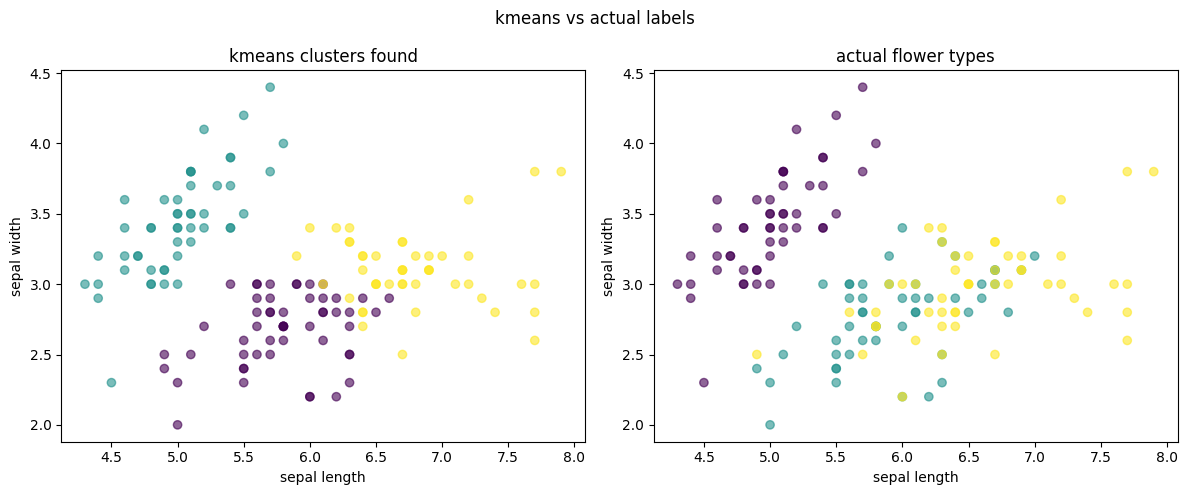

In [4]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

iris = load_iris()
x = iris.data
y_true = iris.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

model = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred = model.fit_predict(x_scaled)

print("iris clustering - no labels used")
print("-" * 35)

ari = adjusted_rand_score(y_true, y_pred)
print("adjusted rand score:", round(ari, 3))
print("(1.0 = perfect, 0 = random)")
print("-" * 35)

for i in range(3):
    count = list(y_pred).count(i)
    print("cluster", i, "-> points:", count)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x[:, 0], x[:, 1], c=y_pred, cmap="viridis", alpha=0.6)
axes[0].set_title("kmeans clusters found")
axes[0].set_xlabel("sepal length")
axes[0].set_ylabel("sepal width")

axes[1].scatter(x[:, 0], x[:, 1], c=y_true, cmap="viridis", alpha=0.6)
axes[1].set_title("actual flower types")
axes[1].set_xlabel("sepal length")
axes[1].set_ylabel("sepal width")

plt.suptitle("kmeans vs actual labels")
plt.tight_layout()
plt.show()